## Survival Analysis: Time-to-Default Estimation

### *Author: Marzieh Safari*

#### Data Sources:
<a href="https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv?resource=download&select=loan.csv"> Lending Club Loan Data - Kaggle </a>

<a href="https://fred.stlouisfed.org/"> Federal Reserve Bank of St. Louis </a>

### Project Objectives  
#### 1. Execute "Time-to-Default" Estimation
* Beyond Binary Classification:  
Building on previous work that predicted if a default occurs, this phase transitions to predicting when it occurs (Time-to-Event analysis).  
* Longitudinal Feature Engineering:  
By calculating the delta between issue_date and last_payment_date for "Charged Off" loans, I derived the precise "Months to Default."
* Strategic Alignment:  
This high-level temporal insight aligns with **Expected Credit Loss (ECL)** frameworks, providing a more granular view of portfolio risk than static classification.  
#### 2. Results and Actionable Insights
##### The Portfolio Risk Profile
* Survival Modeling:  
Utilized **Kaplan-Meier estimates** to model the survival probability of a 74,000-loan portfolio.
* Critical Risk Window:  
Identified a critical risk horizon between **months 5 and 40**. During this 35-month window, the cumulative survival probability declined from nearly 100% to 75%, representing the period of peak hazard for the portfolio. Beyond month 60, while a sharp decline is observed, the widening confidence intervals and dwindling 'At-Risk' count (n < 150) suggest that risk interventions are most effective if deployed before the 40-month maturity mark.
* Proactive Intervention:  
This longitudinal analysis provides the foundation for time-dependent classifiers, enabling the bank to trigger risk interventions prior to peak default periods.  
##### Multivariate Risk Drivers (Cox Proportional Hazards)
To analyze granular risk drivers, I implemented a **Cox Proportional Hazards (CPH)** model. This allowed for the quantification of specific features on the baseline hazard of default.
* Model Performance:  
The model achieved a **Concordance Index of 0.69**, indicating strong discriminative power in ranking borrowers by their relative risk of failure ($p < 0.005$).  
* Key Risk Determinants:  
-- **Annual Income & Interest Rate:** These surfaced as the most prominent drivers of the hazard rate.  
-- **Home Ownership:** Renters demonstrated a significantly higher hazard (shorter time-to-default) compared to homeowners.

#### Strategic Conclusion:  
##### *Borrowers characterized by low income, rental status, and high-interest loan products exhibit the highest "acceleration" toward default. This insight allows for more precise risk-based pricing and capital allocation strategies.*

### Importing Libraries:

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Data:

In [ ]:
df = pd.read_csv(r'D:\Data Science\python-codes\Projects\Banking\loan.csv')
df.head()

### Data Wrangling:

In [114]:
selected_cols = [
 'loan_amnt','int_rate','installment','emp_length','home_ownership',
 'annual_inc','issue_d','loan_status','dti',
 'delinq_2yrs', 'pub_rec', 'revol_util', 'addr_state', 'last_pymnt_d', 'term', 'chargeoff_within_12_mths'
]

df_selected = df[selected_cols].copy()

In [115]:
df_selected.head()

,loan_amnt,int_rate,installment,emp_length,home_ownership,annual_inc,issue_d,loan_status,dti,delinq_2yrs,pub_rec,revol_util,addr_state,last_pymnt_d,term,chargeoff_within_12_mths
0,2500,13.56,84.92,10+ years,RENT,55000.0,Dec-2018,Current,18.24,0.0,1.0,10.3,NY,Feb-2019,36 months,0.0
1,30000,18.94,777.23,10+ years,MORTGAGE,90000.0,Dec-2018,Current,26.52,0.0,1.0,24.2,LA,Feb-2019,60 months,0.0
2,5000,17.97,180.69,6 years,MORTGAGE,59280.0,Dec-2018,Current,10.51,0.0,0.0,19.1,MI,Feb-2019,36 months,0.0
3,4000,18.94,146.51,10+ years,MORTGAGE,92000.0,Dec-2018,Current,16.74,0.0,0.0,78.1,WA,Feb-2019,36 months,0.0
4,30000,16.14,731.78,10+ years,MORTGAGE,57250.0,Dec-2018,Current,26.35,0.0,0.0,3.6,MD,Feb-2019,60 months,0.0


In [ ]:
df_selected.isnull().sum()

In [117]:
df_selected = df_selected[df_selected['annual_inc'] <= 2000000]

In [118]:
df_selected = df_selected[df_selected['pub_rec'] <= 75]

In [119]:
df_selected['emp_length'] = df_selected['emp_length'].fillna('Unknown')
df_selected['annual_inc'] = df_selected['annual_inc'].fillna(df_selected['annual_inc'].median())
df_selected['dti'] = df_selected['dti'].fillna(df_selected['dti'].median())
df_selected = df_selected[df_selected['delinq_2yrs'].notnull()] 
df_selected = df_selected[df_selected['pub_rec'].notnull()]  
df_selected['revol_util'] = df_selected['revol_util'].fillna(df_selected['revol_util'].median())
df_selected = df_selected[df_selected['last_pymnt_d'].notnull()] 
df_selected = df_selected.dropna(subset=['chargeoff_within_12_mths'])

In [ ]:
df_selected.isnull().sum()

In [121]:
cols = ['delinq_2yrs', 'pub_rec']
df_selected[cols] = df_selected[cols].astype(int)

In [ ]:
# Convert to datetime
df_selected['issue_d'] = pd.to_datetime(df_selected['issue_d'])

In [ ]:
df_selected['last_pymnt_d'] = pd.to_datetime(df_selected['last_pymnt_d'])

In [124]:
# The "latest" date is our observation cutoff
snapshot_date = df_selected['last_pymnt_d'].max()
print(f"Dataset Snapshot Date: {snapshot_date}")

Dataset Snapshot Date: 2019-02-01 00:00:00


In [125]:
# Create a temporary 'end_date' column
# For Charged Off/Fully Paid, use their last payment date.
# For Current, use the snapshot_date.

df_selected['temp_end_date'] = df_selected['last_pymnt_d']

# Fill 'Current' or missing dates with the snapshot date
df_selected.loc[df_selected['loan_status'] == 'Current', 'temp_end_date'] = snapshot_date


In [126]:
# Calculate months on book
from dateutil.relativedelta import relativedelta

def months_between(start, end):
    if pd.isna(start) or pd.isna(end):
        return np.nan
    rd = relativedelta(end, start)
    return rd.years * 12 + rd.months + rd.days/30.0

df_selected['duration'] = df_selected.apply(lambda r: months_between(r.issue_d, r.last_pymnt_d), axis=1)

In [ ]:
df_selected.head()

In [ ]:
df_selected = df_selected[df_selected['addr_state'] == 'OH']
df_selected = df_selected.drop('temp_end_date', axis=1)
df_selected.head()

In [129]:
df_selected.shape

(75069, 17)

In [130]:
df_selected['loan_status'].value_counts()

loan_status
Fully Paid                                             33605
Current                                                31660
Charged Off                                             8774
Late (31-120 days)                                       552
In Grace Period                                          286
Late (16-30 days)                                         88
Does not meet the credit policy. Status:Fully Paid        84
Does not meet the credit policy. Status:Charged Off       18
Default                                                    2
Name: count, dtype: int64

In [131]:
bad_statuses = ['Charged Off', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
'Does not meet the credit policy. Status:Charged Off', 'Default' ]  # or whatever status labels you treat as bad
# 3. Binary target
df_selected['target'] = df_selected['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)

print(df_selected['target'].value_counts(normalize=True))

target
0    0.870519
1    0.129481
Name: proportion, dtype: float64


In [132]:
df_selected.shape

(75069, 18)

In [133]:
# Define the event
df_selected['event'] = (df_selected['loan_status'].isin(bad_statuses)).astype(int)
df_selected['event'].value_counts()

event
0    65349
1     9720
Name: count, dtype: int64

In [ ]:
df_selected.head()

In [135]:
# Get macroeconomic data from FRED with the fredapi 
from fredapi import Fred

fred = Fred(api_key='c4f1bd99bb93093449d2ff4af4d13eca')

series_ids = {
    'CPI': 'CPIAUCSL',
    'Fed_Funds_Rate': 'FEDFUNDS',
    'Ohio Unemployment Rate': 'OHUR'
}

data_dict = {name: fred.get_series(series_id) for name, series_id in series_ids.items()}

macro_df = pd.DataFrame(data_dict)
macro_df.index.name = 'Date'
macro_df = macro_df.dropna()

print(macro_df.head())
macro_df.info()

             CPI  Fed_Funds_Rate  Ohio Unemployment Rate
Date                                                    
1976-01-01  55.8            4.87                     8.1
1976-02-01  55.9            4.77                     8.1
1976-03-01  56.0            4.84                     8.1
1976-04-01  56.1            4.82                     7.9
1976-05-01  56.4            5.29                     7.8
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 599 entries, 1976-01-01 to 2025-12-01
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CPI                     599 non-null    float64
 1   Fed_Funds_Rate          599 non-null    float64
 2   Ohio Unemployment Rate  599 non-null    float64
dtypes: float64(3)
memory usage: 18.7 KB


In [136]:
# See if unemployment 3 months ago predicts today's default
macro_df['Unemployment_lag3'] = macro_df['Ohio Unemployment Rate'].shift(3)

# See if the CHANGE in interest rates matters
macro_df['Fed_Funds_Diff'] = macro_df['Fed_Funds_Rate'].diff(periods=3).round(2)

macro_df.head(10)

,CPI,Fed_Funds_Rate,Ohio Unemployment Rate,Unemployment_lag3,Fed_Funds_Diff
Date,,,,,
1976-01-01,55.8,4.87,8.1,NaN,NaN
1976-02-01,55.9,4.77,8.1,NaN,NaN
1976-03-01,56.0,4.84,8.1,NaN,NaN
1976-04-01,56.1,4.82,7.9,8.1,-0.05
1976-05-01,56.4,5.29,7.8,8.1,0.52
1976-06-01,56.7,5.48,7.6,8.1,0.64
1976-07-01,57.0,5.31,7.5,7.9,0.49
1976-08-01,57.3,5.29,7.5,7.8,0.00
1976-09-01,57.6,5.25,7.4,7.6,-0.23


In [137]:
df_selected['issue_d'] = pd.to_datetime(df_selected['issue_d'], format='%b-%Y', errors='coerce')
df_merged = df_selected.merge(macro_df, left_on='issue_d', right_index=True, how='left')
df_merged.head()

df_merged.to_csv(r'D:\Data Science\python-codes\Projects\Banking\df_merged1.csv', index=False)

In [ ]:
df_merged = df_merged.drop(columns=['Fed_Funds_Rate', 'Ohio Unemployment Rate'])
df_merged.head()

In [140]:
df_merged.shape

(75069, 22)

In [ ]:
!pip install lifelines

In [142]:

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Create the 'Duration' (Months on Book)
# reate the 'Observed' flag (1 if Default/Charged Off, 0 otherwise)
durations = df_merged['duration']
event_observed = df_merged['event'] 

# Initialize the fitter
kmf = KaplanMeierFitter()

# Fit the data
kmf.fit(durations, event_observed, label='LendingClub Loan Survival')

<lifelines.KaplanMeierFitter:"LendingClub Loan Survival", fitted with 75069 total observations, 65349 right-censored observations>

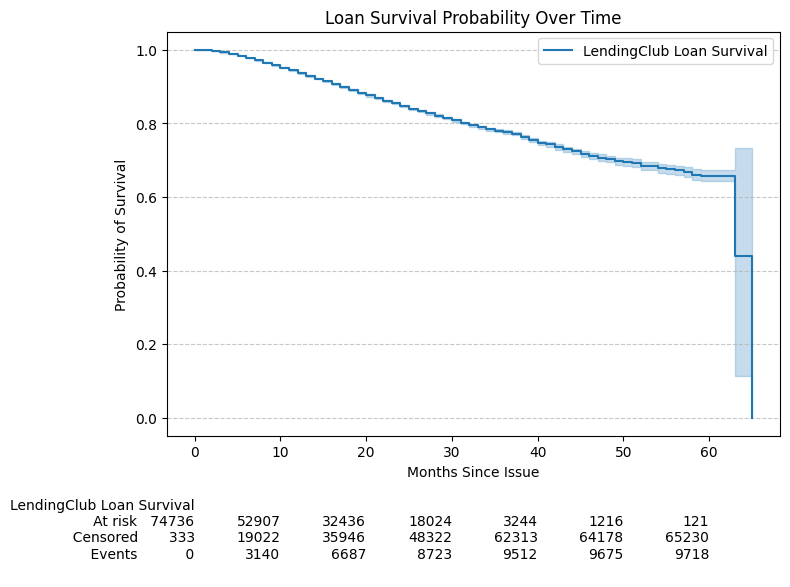

In [165]:
# Plot the survival function
# Generate the plot and capture the 'ax' object
plt.figure(figsize=(8, 6))
ax = kmf.plot_survival_function(at_risk_counts=True)

# Set the labels directly on that specific axis
ax.set_title('Loan Survival Probability Over Time')
ax.set_xlabel('Months Since Issue')
ax.set_ylabel('Probability of Survival') 
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(r'D:\Data Science\python-codes\Projects\Banking\km_plot.png')
plt.show()

In [ ]:
df_merged['emp_length'].value_counts()

In [ ]:
import pandas as pd
import numpy as np

# Strip everything that isn't a number (e.g., "10+ years" -> "10")
# We use .str.extract('(\d+)') to grab the first sequence of digits
df_merged['emp_length_num'] = df_merged['emp_length'].str.extract('(\d+)').astype(float)

# Define the numeric edges (must be strictly increasing)
numeric_bins = [0, 4, 9, 100]

# Define the labels 
labels = ['less than five years', 'five to ten years', 'ten plus years']

# Run the cut on the numeric column
df_merged['emp_length_binned'] = pd.cut(df_merged['emp_length_num'], bins=numeric_bins, labels=labels, include_lowest=True)

# Handle the "Unknown" (NaN) values
df_merged['emp_length_binned'] = df_merged['emp_length_binned'].cat.add_categories('Unknown').fillna('Unknown')

In [ ]:
df_merged.head()

In [147]:
df_merged['emp_length_binned'].value_counts()

emp_length_binned
ten plus years          27358
less than five years    26307
five to ten years       15974
Unknown                  5430
Name: count, dtype: int64

In [148]:
def encode_emp_length(x):
    if x == 'ten plus years':
        return 1
    elif x == 'five to ten years':
        return 2
    elif x == 'less than five years':
        return 3
    else:
        # This handles 'Unknown' or any unexpected values
        return 0

df_merged['emp_length_encoded'] = df_merged['emp_length_binned'].apply(encode_emp_length)

# Check counts
print(df_merged['emp_length_encoded'].value_counts())

emp_length_encoded
1    27358
3    26307
2    15974
0     5430
Name: count, dtype: int64


In [149]:
df_merged['home_ownership'].value_counts()

home_ownership
MORTGAGE    44667
RENT        21640
OWN          8731
ANY            26
OTHER           3
NONE            2
Name: count, dtype: int64

In [150]:
def encode_home_ownership(x):
    if x == 'MORTGAGE':
        return 1
    elif x == 'RENT':
        return 2
    elif x == 'OWN':
        return 3
    else:
        return 0

df_merged['home_ownership'] = df_merged['home_ownership'].apply(encode_home_ownership)

        
df_merged['home_ownership'].value_counts()

home_ownership
1    44667
2    21640
3     8731
0       31
Name: count, dtype: int64

In [ ]:
df_merged['annual_inc'].describe()

In [154]:
def encode_annual_inc(x):
    if x < 2000000 and x >= 100000:
        return 1
    elif x < 100000 and x >= 10000:
        return 2
    else:
        return 3

df_merged['annual_inc_encoded'] = df_merged['annual_inc'].apply(encode_annual_inc)

        
df_merged['annual_inc_encoded'].value_counts()

annual_inc_encoded
2    63209
1    11666
3      194
Name: count, dtype: int64

In [ ]:
df_merged.head()

<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
C:\Users\marzs\AppData\Local\Temp\ipykernel_30292\2892380477.py:23: SyntaxWarning: invalid escape sequence '\d'
  cph_data['term'] = cph_data['term'].str.extract('(\d+)').astype(int)
C:\Users\marzs\AppData\Local\Temp\ipykernel_30292\2892380477.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cph_data['term'] = cph_data['term'].str.extract('(\d+)').astype(int)


<lifelines.CoxPHFitter: fitted with 75069 total observations, 65349 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 75069
number of events observed = 9720
   partial log-likelihood = -100430.84
         time fit was run = 2026-04-05 00:11:15 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
loan_amnt                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
int_rate                  0.12      1.13      0.00            0.11            0.12                1.12                1.13
installment               0.00      1.00      0.00            0.00            0.00                1.00                1.00
delinq_2yrs               0.01      1.01      0.01           -0.02            0.03                0.98                1.03
pub_rec                   0.03      1.03      0.01            0.01            0.05                1.01                1.05
revol_util               -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
term                     -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
dti                       0.00      1.00      0.00           -0.00            0.00                1.00                1.00
chargeoff_within_12_mths -0.18      0.84      0.12           -0.41            0.06                0.66                1.06
annual_inc_encoded        0.23      1.26      0.03            0.17            0.30                1.18                1.35
emp_length_encoded       -0.02      0.98      0.01           -0.04            0.00                0.96                1.00
CPI                      -0.03      0.97      0.00           -0.04           -0.02                0.96                0.98
home_ownership            0.08      1.09      0.01            0.05            0.11                1.05                1.12
Unemployment_lag3        -0.23      0.80      0.02           -0.26           -0.20                0.77                0.82
Fed_Funds_Diff            0.04      1.05      0.11           -0.17            0.25                0.85                1.29

                          cmp to      z      p  -log2(p)
covariate                                               
loan_amnt                   0.00  -1.80   0.07      3.78
int_rate                    0.00  40.77 <0.005       inf
installment                 0.00   2.09   0.04      4.78
delinq_2yrs                 0.00   0.48   0.63      0.66
pub_rec                     0.00   3.09 <0.005      8.98
revol_util                  0.00  -5.45 <0.005     24.22
term                        0.00  -1.73   0.08      3.58
dti                         0.00   1.85   0.06      3.96
chargeoff_within_12_mths    0.00  -1.49   0.14      2.87
annual_inc_encoded          0.00   6.74 <0.005     35.90
emp_length_encoded          0.00  -1.64   0.10      3.30
CPI                         0.00  -8.96 <0.005     61.36
home_ownership              0.00   5.54 <0.005     25.02
Unemployment_lag3           0.00 -15.09 <0.005    168.51
Fed_Funds_Diff              0.00   0.41   0.68      0.56
---
Concordance = 0.69
Partial AIC = 200891.69
log-likelihood ratio test = 3626.59 on 15 df
-log2(p) of ll-ratio test = inf

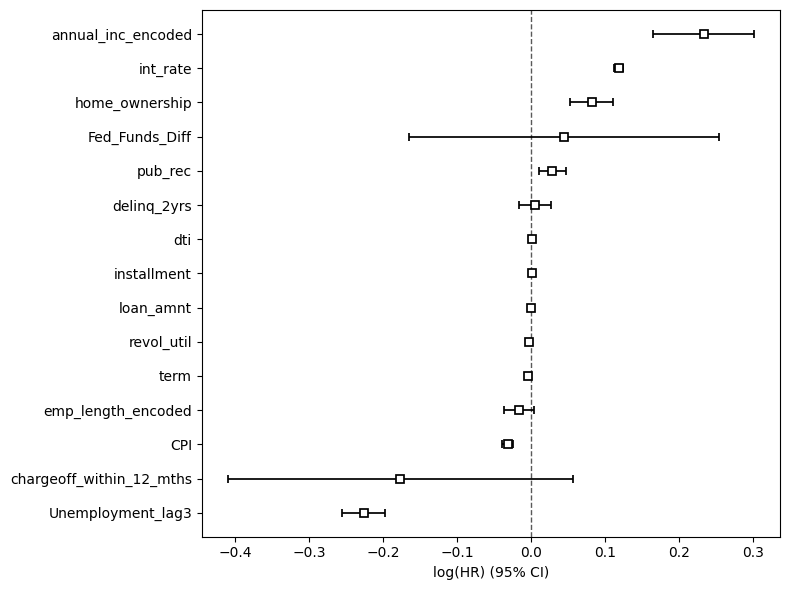

In [167]:
from lifelines import CoxPHFitter

# Select your features + duration and event
cph_data = df_merged[['loan_amnt',
 'int_rate', 
 'installment', 
 'delinq_2yrs', 
 'pub_rec', 
 'revol_util', 
 'term',
 'duration', 
 'event', 
 'dti', 
 'chargeoff_within_12_mths',
 'annual_inc_encoded', 
 'emp_length_encoded', 
 'CPI',
 'home_ownership', 
 'Unemployment_lag3', 
 'Fed_Funds_Diff']]

# Convert term to numeric (extract the number of months)
cph_data['term'] = cph_data['term'].str.extract('(\d+)').astype(int)

cph = CoxPHFitter()
cph.fit(cph_data, duration_col='duration', event_col='event')

# See which economic factors accelerate default
cph.print_summary()

plt.figure(figsize=(8, 6))
ax = cph.plot()

fig = ax.get_figure()
fig.savefig(r'D:\Data Science\python-codes\Projects\Banking\cox_summary.png')

plt.tight_layout()
plt.show()

### Checks on Time-to-Default for  
### - Annual Income 
### - Interest Rate 
### - Home Owenership

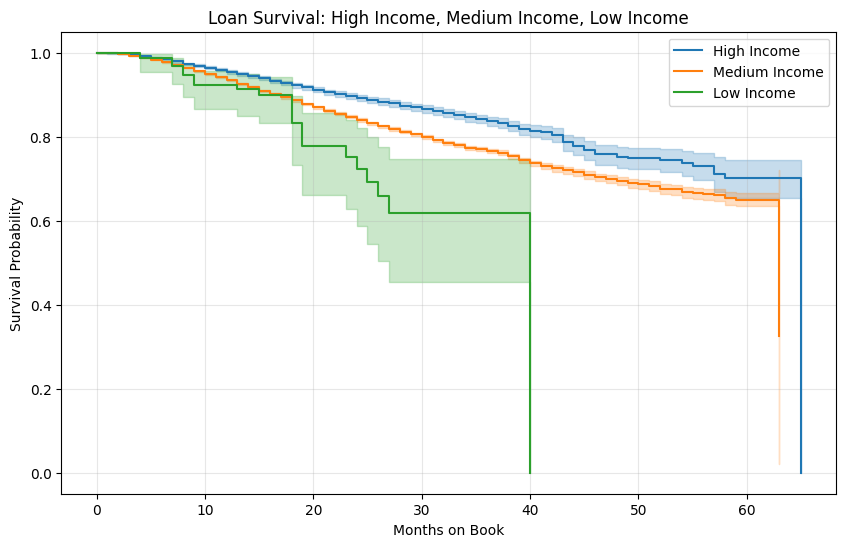

In [157]:
# Define the threshold (e.g., annual_inc_encoded == 1 for high income)
high_income = df_merged[df_merged['annual_inc_encoded'] == 1]
medium_income = df_merged[df_merged['annual_inc_encoded'] == 2]
low_income = df_merged[df_merged['annual_inc_encoded'] == 3]

kmf_high = KaplanMeierFitter()
kmf_medium = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

# Fit both
kmf_high.fit(high_income['duration'], high_income['event'], label='High Income')
kmf_medium.fit(medium_income['duration'], medium_income['event'], label='Medium Income')
kmf_low.fit(low_income['duration'], low_income['event'], label='Low Income')

# Plotting
plt.figure(figsize=(10, 6))
kmf_high.plot_survival_function()
kmf_medium.plot_survival_function()
kmf_low.plot_survival_function()

plt.title('Loan Survival: High Income, Medium Income, Low Income')
plt.xlabel('Months on Book')
plt.ylabel('Survival Probability')
plt.grid(alpha=0.3)
plt.savefig(r'D:\Data Science\python-codes\Projects\Banking\km_plot_Income.png')
plt.show()

##### Data binning for interest rate:

In [159]:
df_merged['int_rate'].describe()

count    75069.000000
mean        13.134992
std          4.792146
min          5.310000
25%          9.710000
50%         12.690000
75%         15.990000
max         30.990000
Name: int_rate, dtype: float64

In [160]:
bins = np.linspace(df_merged['int_rate'].min(), df_merged['int_rate'].max(), num=4)
labels = ['Low Interest', 'Medium Interest', 'High Interest']
df_merged['int_rate_binned'] = pd.cut(df_merged['int_rate'], bins=bins, labels=labels, include_lowest=True)
df_merged['int_rate_binned'].value_counts()

int_rate_binned
Low Interest       45297
Medium Interest    26381
High Interest       3391
Name: count, dtype: int64

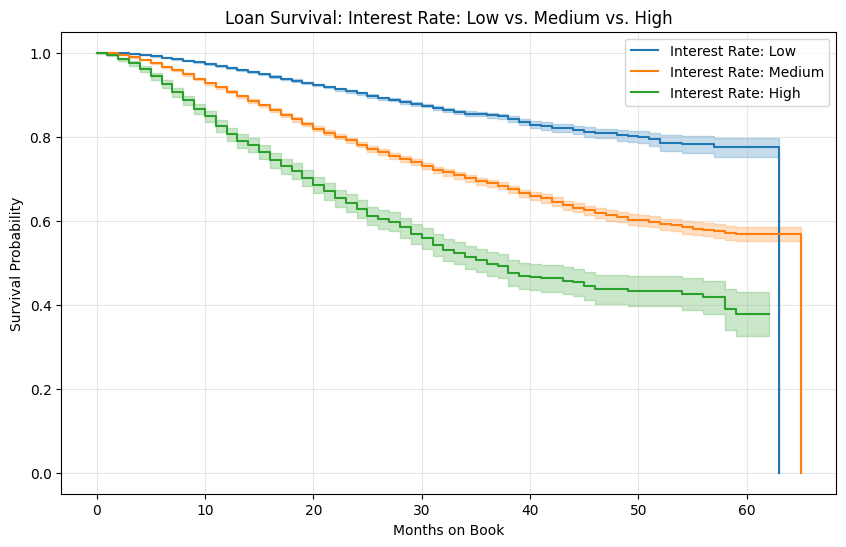

In [ ]:
# Define the threshold (e.g., int_rate_binned == 'Low Interest' for low interest rates)
interest_low = df_merged[df_merged['int_rate_binned'] == 'Low Interest']
interest_medium = df_merged[df_merged['int_rate_binned'] == 'Medium Interest']
interest_high = df_merged[df_merged['int_rate_binned'] == 'High Interest']

kmf_interest_low= KaplanMeierFitter()
kmf_interest_medium = KaplanMeierFitter()
kmf_interest_high = KaplanMeierFitter()

# Fit both
kmf_interest_low.fit(interest_low['duration'], interest_low['event'], label='Interest Rate: Low')
kmf_interest_medium.fit(interest_medium['duration'], interest_medium['event'], label='Interest Rate: Medium')
kmf_interest_high.fit(interest_high['duration'], interest_high['event'], label='Interest Rate: High')

# Plotting
plt.figure(figsize=(10, 6))
kmf_interest_low.plot_survival_function()
kmf_interest_medium.plot_survival_function()
kmf_interest_high.plot_survival_function()

plt.title('Loan Survival: Interest Rate: Low vs. Medium vs. High')
plt.xlabel('Months on Book')
plt.ylabel('Survival Probability')
plt.grid(alpha=0.3)
plt.savefig(r'D:\Data Science\python-codes\Projects\Banking\km_plot_InterestRate.png')
plt.show()

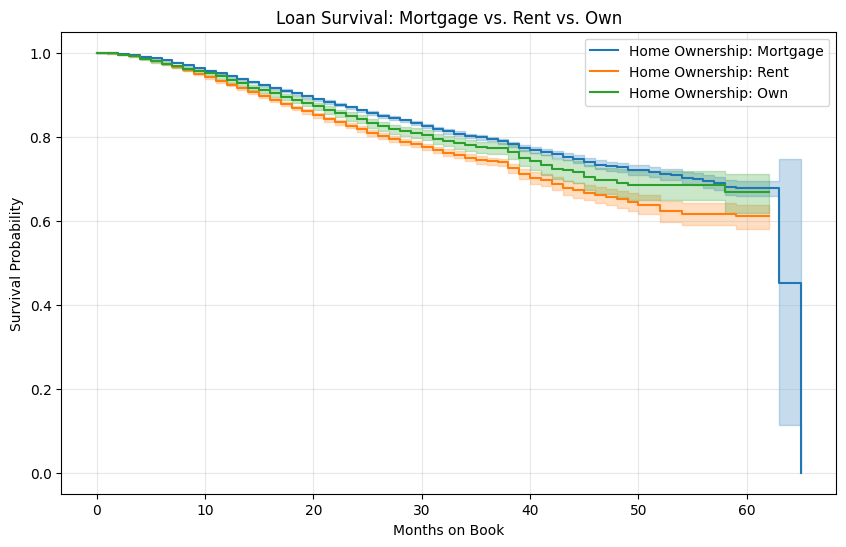

In [168]:
# Define the threshold (e.g., home_ownership == 1 for mortgage)
home_mortgage = df_merged[df_merged['home_ownership'] == 1]
home_rent = df_merged[df_merged['home_ownership'] == 2]
home_own = df_merged[df_merged['home_ownership'] == 3]

kmf_mortgage = KaplanMeierFitter()
kmf_rent = KaplanMeierFitter()
kmf_own = KaplanMeierFitter()

# Fit both
kmf_mortgage.fit(home_mortgage['duration'], home_mortgage['event'], label='Home Ownership: Mortgage')
kmf_rent.fit(home_rent['duration'], home_rent['event'], label='Home Ownership: Rent')
kmf_own.fit(home_own['duration'], home_own['event'], label='Home Ownership: Own')

# Plotting
plt.figure(figsize=(10, 6))
kmf_mortgage.plot_survival_function()
kmf_rent.plot_survival_function()
kmf_own.plot_survival_function()

plt.title('Loan Survival: Mortgage vs. Rent vs. Own')
plt.xlabel('Months on Book')
plt.ylabel('Survival Probability')
plt.grid(alpha=0.3)
plt.savefig(r'D:\Data Science\python-codes\Projects\Banking\km_plot_HomeOwnership.png')
plt.show()